<a href="https://colab.research.google.com/github/kavithaBakka/CodeAlpha_CarPricePrediction/blob/main/CodeAlpha_UnemploymentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
# ==========================================
# CodeAlpha Internship
# Task 2 - Unemployment Analysis with Python
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [120]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (7).csv


In [121]:
df = pd.read_csv("Unemployment in India.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [122]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [123]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (768, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [124]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [125]:
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [126]:
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (740, 7)


In [127]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [128]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


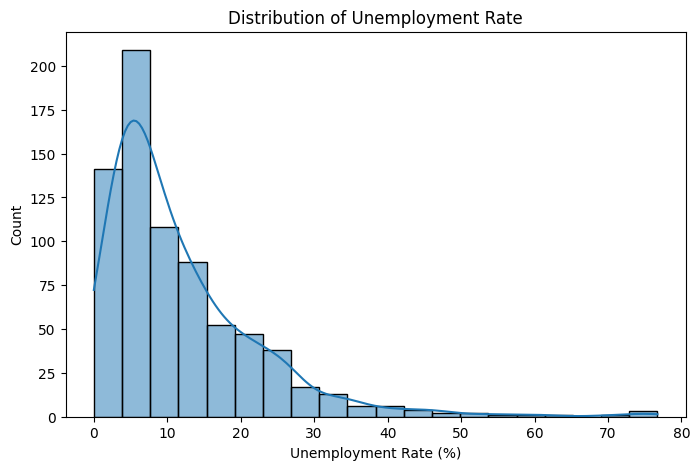

In [129]:
plt.figure(figsize=(8,5))

sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")

plt.xlabel("Unemployment Rate (%)")

plt.show()

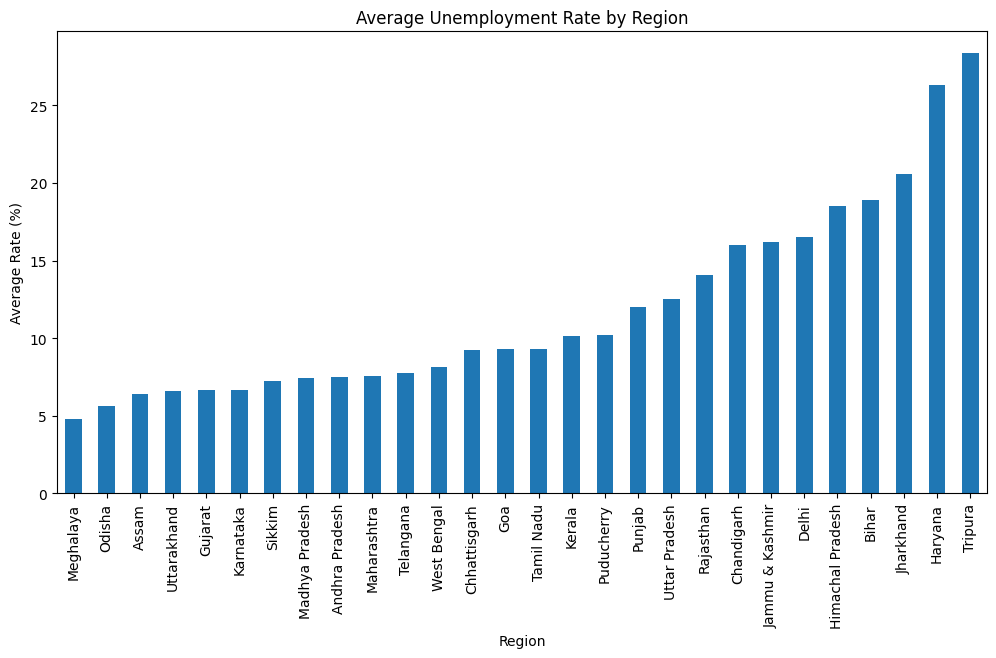

In [130]:
plt.figure(figsize=(12,6))

df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values().plot(kind='bar')

plt.title("Average Unemployment Rate by Region")

plt.ylabel("Average Rate (%)")

plt.xticks(rotation=90)

plt.show()

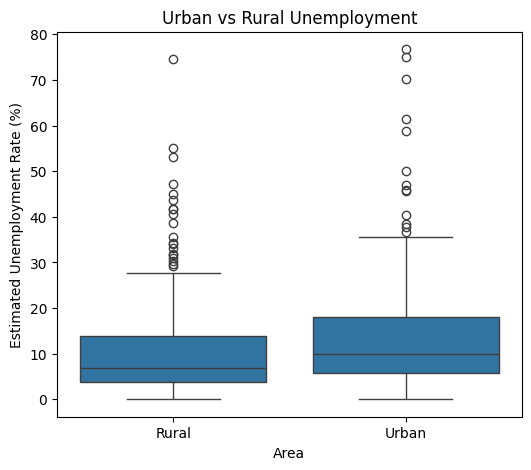

In [131]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df,
            x='Area',
            y='Estimated Unemployment Rate (%)')

plt.title("Urban vs Rural Unemployment")

plt.show()

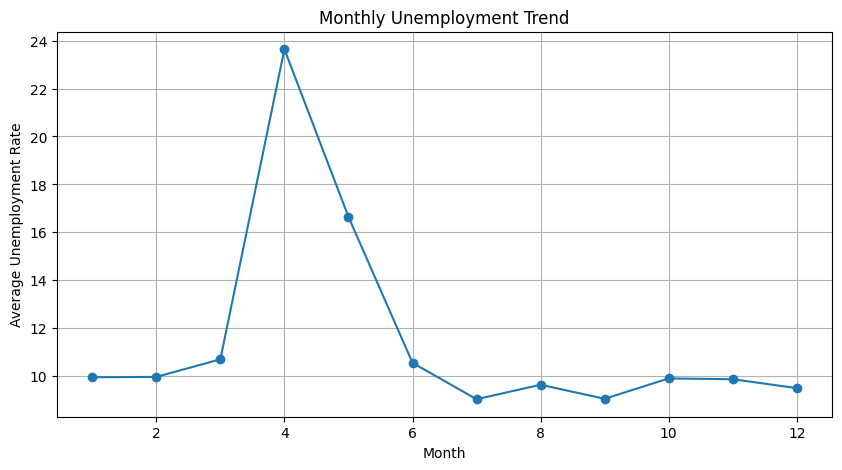

In [132]:
monthly = df.groupby(df['Date'].dt.month)['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))

monthly.plot(marker='o')

plt.title("Monthly Unemployment Trend")

plt.xlabel("Month")

plt.ylabel("Average Unemployment Rate")

plt.grid(True)

plt.show()

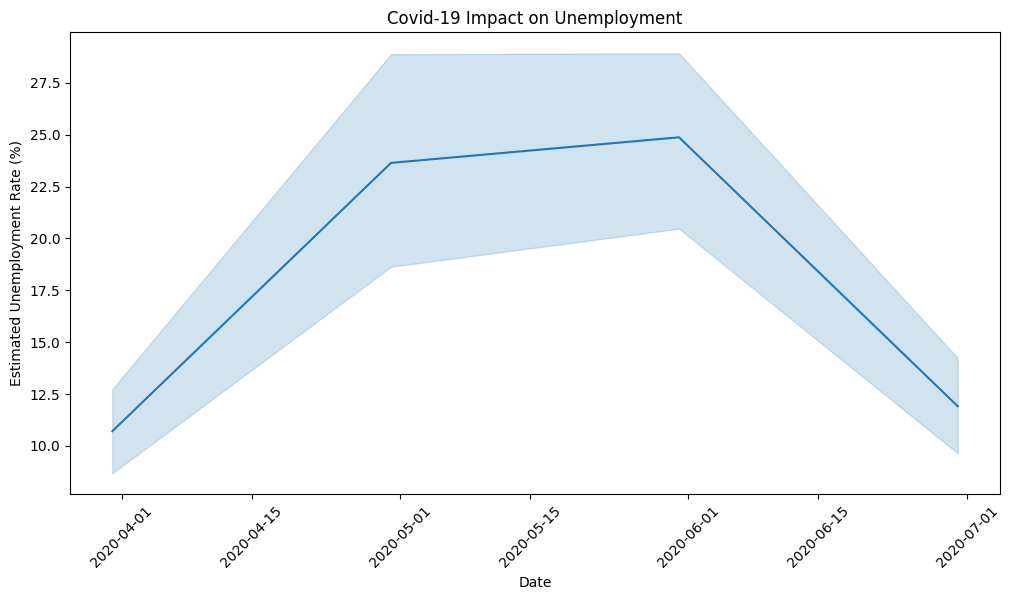

In [133]:
covid = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(12,6))

sns.lineplot(data=covid,
             x='Date',
             y='Estimated Unemployment Rate (%)')

plt.title("Covid-19 Impact on Unemployment")

plt.xticks(rotation=45)

plt.show()

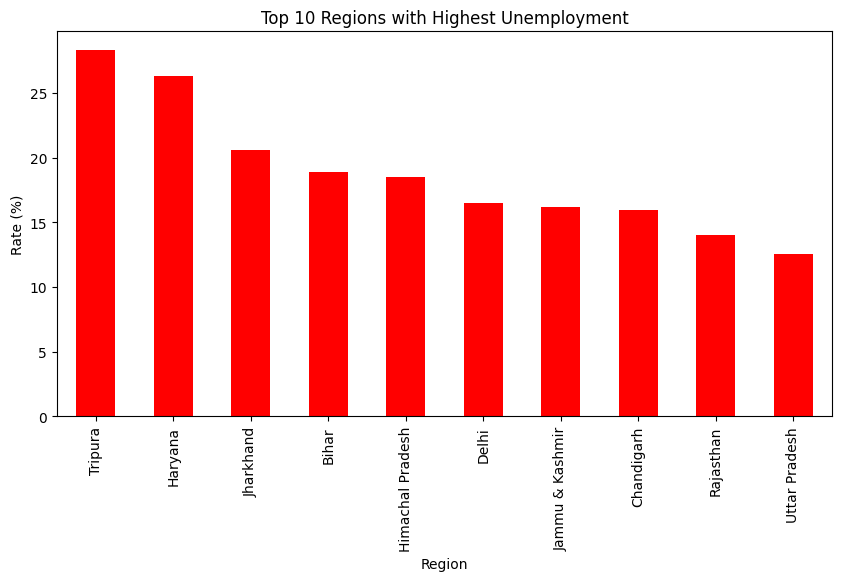

In [134]:
top = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top.plot(kind='bar', color='red')

plt.title("Top 10 Regions with Highest Unemployment")

plt.ylabel("Rate (%)")

plt.show()

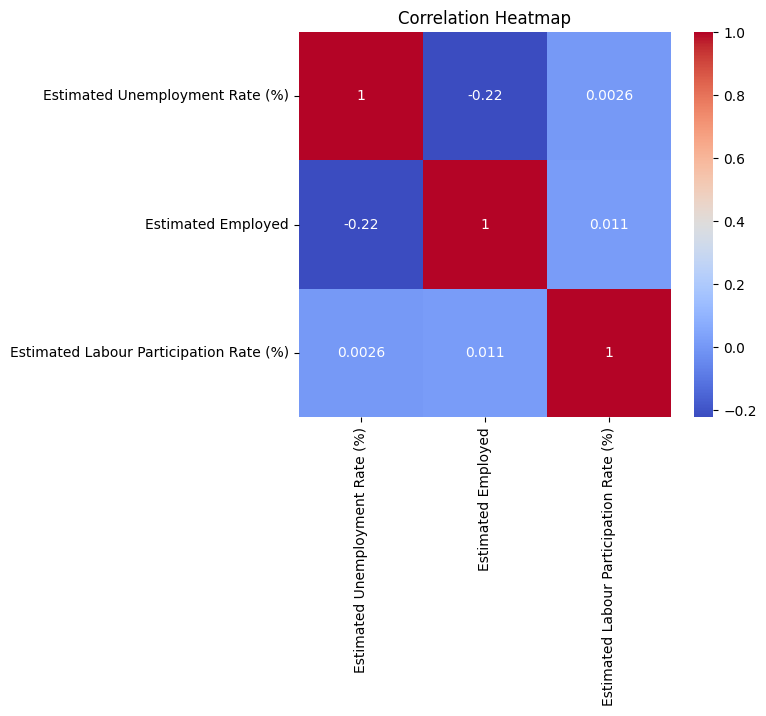

In [135]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(6,5))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [136]:
print("========== Key Insights ==========")

print("Average Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].mean(),2),"%")

print("Highest Region:",
      df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().idxmax())

print("Lowest Region:",
      df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().idxmin())

print("Average Labour Participation Rate:",
      round(df['Estimated Labour Participation Rate (%)'].mean(),2),"%")

========== Key Insights ==========
Average Unemployment Rate: 11.79 %
Highest Region: Tripura
Lowest Region: Meghalaya
Average Labour Participation Rate: 42.63 %


In [137]:
print("===========================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("Task : Unemployment Analysis with Python")
print("Platform : Google Colab")
print("Libraries Used : Pandas, NumPy, Matplotlib, Seaborn")
print()
print("Conclusion:")
print("- Dataset cleaned successfully.")
print("- Unemployment trends were analyzed across different regions.")
print("- Monthly and regional patterns were visualized.")
print("- Covid-19 period showed noticeable changes in unemployment.")
print("- The analysis provides insights that can support economic and social policy decisions.")
print("===========================================")

PROJECT COMPLETED SUCCESSFULLY
Task : Unemployment Analysis with Python
Platform : Google Colab
Libraries Used : Pandas, NumPy, Matplotlib, Seaborn

Conclusion:
- Dataset cleaned successfully.
- Unemployment trends were analyzed across different regions.
- Monthly and regional patterns were visualized.
- Covid-19 period showed noticeable changes in unemployment.
- The analysis provides insights that can support economic and social policy decisions.
